# Clustering Geográfico de POIs en Barcelona

Este notebook implementa un análisis de clustering geográfico para agrupar los puntos de interés (POIs) de Barcelona en función de su ubicación espacial. Utilizando el algoritmo K-Means, se segmenta el espacio geográfico para facilitar la generación de rutas de recomendación personalizadas.

El objetivo principal es identificar zonas geográficas naturales donde se concentran los POIs, lo que permitirá crear recomendaciones más contextuales y eficientes en términos de distancia y tiempo de viaje.

## Objetivo del notebook

La función de este bloque dentro del TFM es aportar una señal espacial reutilizable para fases posteriores.

En concreto, el notebook busca:

1. agrupar POIs por proximidad geográfica
2. identificar un número razonable de clusters
3. generar la feature `cluster_geo`
4. dejar preparada una señal espacial interpretable para el futuro sistema híbrido

Este notebook no construye todavía la ruta final, pero sí aporta una pieza clave para evitar recorridos geográficamente incoherentes más adelante.

## ***1. Importación de Librerías y Carga de Datos***

En esta sección, importamos las librerías necesarias para el análisis de datos y el clustering, incluyendo pandas para manipulación de datos, scikit-learn para el algoritmo K-Means, y matplotlib para visualizaciones. Posteriormente, cargamos el dataset de POIs procesados previamente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cargamos el parquet con los POIs ya procesados previamente
df = pd.read_parquet("../data/pois_barcelona_procesados.parquet")

# Sacamos una muestra visual de los datos para comprobar que se hayan cargado correctamente
df.head()

,id,name,category,subcategory,latitude,longitude,city,description,rating,match_confidence,...,opening_hours_source,has_opening_hours,is_24_7,is_likely_open,has_match_confidence,score,has_valid_source,visit_duration,tags,tags_str
0,3,Biblioteca de Cataluña,cultural,library,41.3810,2.16951,Barcelona,national library,4.2,0.930000,...,OSM,True,False,True,True,3.21900,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor
1,34,Esquerra de l'Eixample,cultural,library,41.3868,2.15205,Barcelona,neighborhood,4.1,0.503766,...,NaN,False,False,False,False,2.56796,False,60,"[culture, indoor]",culture|indoor
2,35,Can Mariner (Barcelona),cultural,library,41.4312,2.16056,Barcelona,masia,4.1,0.650000,...,OSM,True,False,True,True,3.06500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor
3,111,Archivo Histórico de la Ciudad de Barcelona,cultural,library,41.3841,2.17567,Barcelona,archive,4.3,0.503766,...,NaN,False,False,False,False,2.68696,False,60,"[culture, indoor]",culture|indoor
4,112,Arxiu Diocesà de Barcelona,cultural,library,41.3837,2.17534,Barcelona,episcopal archive,4.2,0.750000,...,OSM,True,False,True,True,3.16500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor


## ***2. Preparación de Datos para Clustering***

Creamos un DataFrame específico para el análisis de clustering geográfico, seleccionando únicamente las columnas relevantes. Eliminamos registros sin coordenadas válidas para asegurar que todos los datos sean utilizables por el algoritmo K-Means.

In [2]:
# Creamos un nuevo DataFrame específico para el clustering geográfico
# Seleccionamos solo las columnas que pueden ser útiles para:
# - agrupar por ubicación (latitude, longitude)
# - analizar luego los clusters (name, category, etc.)
df_geo = df[[
    'id',
    'name',
    'category',
    'subcategory',
    'latitude',         # Latitud → variable clave para clustering
    'longitude',        # Longitud → variable clave para clustering
    'rating',
    'score',
    'visit_duration'
]].copy()   # Hacemos copia para no modificar el DataFrame original

# Eliminamos filas que no tienen coordenadas válidas
# K-Means necesita valores numéricos en todas las filas
df_geo = df_geo.dropna(subset=['latitude', 'longitude'])
df_geo.head()

,id,name,category,subcategory,latitude,longitude,rating,score,visit_duration
0,3,Biblioteca de Cataluña,cultural,library,41.3810,2.16951,4.2,3.21900,60
1,34,Esquerra de l'Eixample,cultural,library,41.3868,2.15205,4.1,2.56796,60
2,35,Can Mariner (Barcelona),cultural,library,41.4312,2.16056,4.1,3.06500,60
3,111,Archivo Histórico de la Ciudad de Barcelona,cultural,library,41.3841,2.17567,4.3,2.68696,60
4,112,Arxiu Diocesà de Barcelona,cultural,library,41.3837,2.17534,4.2,3.16500,60


In [3]:
# Creamos la matriz de entrada X para el modelo de clustering
# Aquí seleccionamos SOLO las variables que el modelo va a usar para agrupar los POIs por ubicación
X = df_geo[['latitude', 'longitude']].copy()

Se construye la matriz de entrada del modelo utilizando exclusivamente las coordenadas geográficas (latitud y longitud), ya que el objetivo es agrupar los puntos de interés en función de su proximidad espacial.

## ***3. Evaluación del Número Óptimo de Clusters***

Utilizamos dos métricas principales para determinar el número óptimo de clusters (k):
- **Método del codo**: Analiza la inercia (suma de distancias cuadradas dentro de clusters) para diferentes valores de k.
- **Silhouette Score**: Mide qué tan similares son los objetos dentro de un cluster comparado con otros clusters.

Probamos valores de k desde 2 hasta 10 para identificar el punto donde las mejoras marginales son mínimas.

### Criterio metodológico de evaluación

En esta fase no interesa solo maximizar una métrica aislada. El objetivo real es encontrar una segmentación útil para el problema de rutas.

Por eso se busca un equilibrio entre:

- compactación interna de los clusters
- separación entre clusters
- interpretabilidad del número final de zonas
- utilidad práctica para estructurar después la recomendación

In [4]:
# Creamos listas vacías para guardar métricas de evaluación
inertia_values = []       # Guardará la inercia (método del codo)
silhouette_values = []    # Guardará el silhouette score (calidad del clustering)

# Definimos el rango de valores de k que vamos a probar
# En este caso, de 2 a 11 clusters
k_range = range(2, 11)

# Probamos distintos valores de k
for k in k_range:
    
    # Creamos el modelo K-Means con k clusters
    kmeans = KMeans(
        n_clusters=k,     # número de clusters
        random_state=42,  # para reproducibilidad (siempre mismo resultado)
        n_init=10         # número de inicializaciones (evita soluciones malas)
    )
    
    # Entrenamos el modelo y obtenemos las etiquetas (cluster asignado a cada punto)
    labels = kmeans.fit_predict(X)
    
    # Guardamos la inercia
    # La inercia mide qué tan compactos son los clusters
    # (menor = mejor)
    inertia_values.append(kmeans.inertia_)
    
    # Guardamos el silhouette score
    # Mide qué tan bien separados están los clusters
    # (más cercano a 1 = mejor)
    silhouette_values.append(silhouette_score(X, labels))

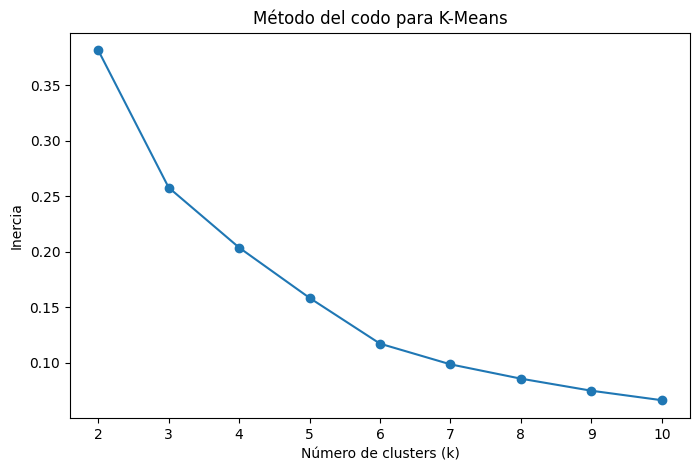

In [5]:
# Creamos una figura para el gráfico del método del codo
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia_values, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para K-Means")
plt.show()

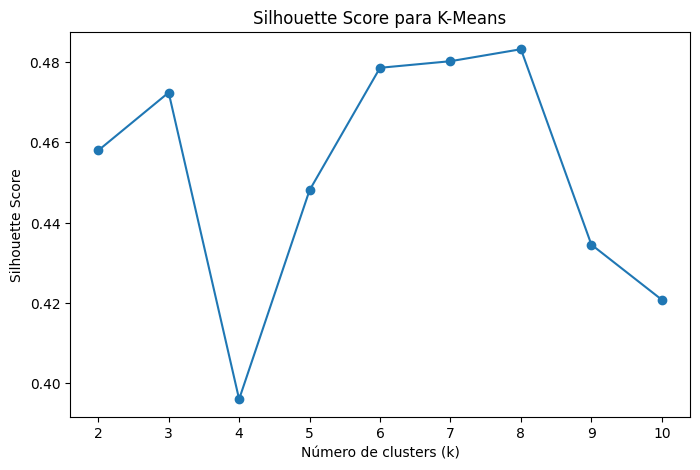

In [6]:
# Creamos una figura para el gráfico del silhouette score
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_values, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para K-Means")
plt.show()

### Interpretación de las métricas

La lectura combinada de ambos gráficos es importante:

- el método del codo ayuda a detectar cuándo las mejoras de compactación dejan de ser sustanciales
- el silhouette score ayuda a medir separación y cohesión

Sin embargo, la elección final no debe ser puramente mecánica. También debe tener sentido práctico para el problema de recomendación de rutas.

## ***4. Aplicación del Modelo Final de Clustering***

Basándonos en los resultados de la evaluación, aplicamos K-Means con k=7 clusters. Este valor proporciona un buen equilibrio entre compactación de clusters y separación geográfica. Asignamos cada POI a su cluster correspondiente.

In [7]:
# Creamos el modelo final de K-Means
# Aquí ya hemos elegido k = 7 como número de clusters
kmeans_final = KMeans(
    n_clusters=7,     # número de clusters elegido tras el análisis (codo + silhouette)
    random_state=42,  # para reproducibilidad (mismo resultado siempre)
    n_init=10         # número de inicializaciones (evita soluciones malas)
)

# Entrenamos el modelo con los datos (latitud y longitud)
# y asignamos a cada POI un cluster
df_geo['cluster_geo'] = kmeans_final.fit_predict(X)

Aunque el silhouette score alcanza su máximo en k≈8, el método del codo indica que a partir de k≈6 las mejoras en compactación son marginales. Dado que el objetivo del clustering es estructurar el espacio para la generación de rutas, se opta por un valor intermedio que equilibre separación y tamaño de los clusters.

In [8]:
# Mostramos que se han asignado los clusters correctamente
df_geo[['name', 'latitude', 'longitude', 'cluster_geo']].head(20)

,name,latitude,longitude,cluster_geo
0,Biblioteca de Cataluña,41.3810,2.16951,1
1,Esquerra de l'Eixample,41.3868,2.15205,3
2,Can Mariner (Barcelona),41.4312,2.16056,0
3,Archivo Histórico de la Ciudad de Barcelona,41.3841,2.17567,1
4,Arxiu Diocesà de Barcelona,41.3837,2.17534,1
5,CRAI Biblioteca de Lletres,41.3864,2.16372,1
6,Cooperativa La Fraternitat,41.3792,2.18882,1
7,Can Saladrigas,41.4015,2.20422,6
8,Escola Professional de la Dona,41.3866,2.17617,1
9,Punto interés,41.3844,2.17183,1


## ***5. Análisis de Resultados del Clustering***

Verificamos la asignación de clusters y analizamos la distribución de POIs por cluster. Esto nos permite entender cómo se han agrupado geográficamente los puntos de interés y validar la calidad de la segmentación.

In [9]:
# Contamos cuántos POIs hay en cada cluster para ver la distribución
df_geo['cluster_geo'].value_counts().sort_index()

cluster_geo
0     65
1    317
2     79
3    137
4     38
5     86
6     52
Name: count, dtype: int64

In [10]:
# Vemos el número total de POIs que tenemos para el clustering
df_geo.shape

(774, 10)

In [11]:
# Mostramos las coordenadas de los centros de cada cluster
centros = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=['latitude_centro', 'longitude_centro']
)

centros

,latitude_centro,longitude_centro
0,41.436532,2.146501
1,41.383571,2.175165
2,41.397611,2.120699
3,41.400763,2.156595
4,41.431492,2.180479
5,41.370291,2.151361
6,41.401540,2.197371


Tras analizar el método del codo y el silhouette score, se selecciona k=7 como valor óptimo. Este valor proporciona un buen equilibrio entre compactación y separación de clusters, permitiendo una segmentación geográfica suficientemente precisa sin fragmentar excesivamente el espacio.

### Valor práctico de `cluster_geo`

La importancia real de este notebook no está solo en el gráfico o en la métrica final, sino en la creación de una nueva feature reutilizable.

`cluster_geo` podrá emplearse después para:

- favorecer rutas espacialmente coherentes
- penalizar saltos geográficos absurdos
- estructurar mejor la exploración de candidatos
- enriquecer el dataset del sistema híbrido final

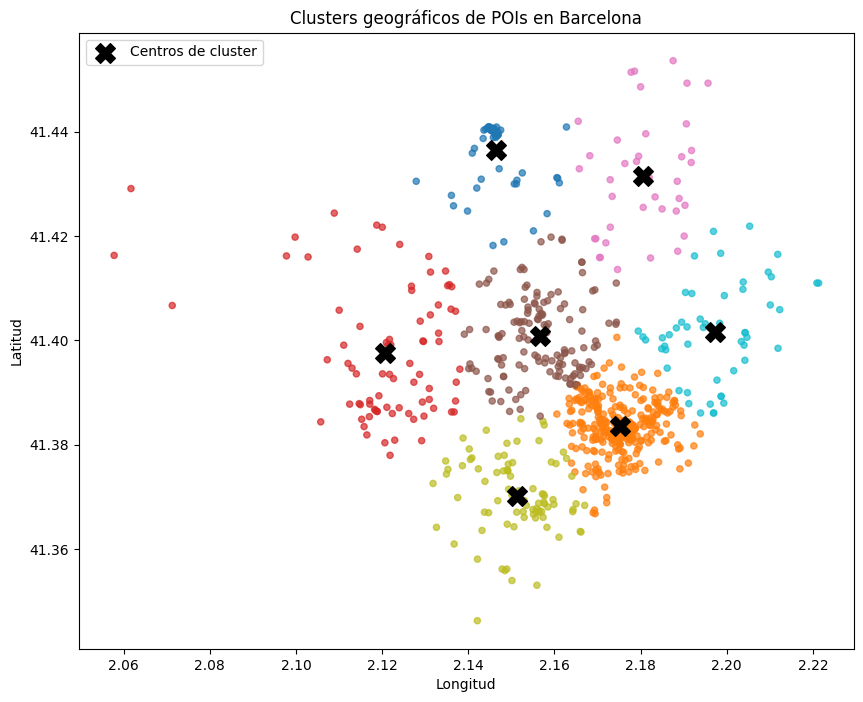

In [12]:
# Dibujamos los POIs coloreados por cluster y los centros de cada cluster
plt.figure(figsize=(10, 8))

# Scatter de todos los POIs
plt.scatter(
    df_geo['longitude'],           # eje X → longitud
    df_geo['latitude'],            # eje Y → latitud
    c=df_geo['cluster_geo'],       # color según cluster
    cmap='tab10',                  # paleta de colores
    s=20,                          # tamaño de punto
    alpha=0.7                      # transparencia
)

# Dibujamos los centros de los clusters
plt.scatter(
    centros['longitude_centro'],   # eje X de centros
    centros['latitude_centro'],    # eje Y de centros
    c='black',                     # color negro para destacar
    s=200,                         # más grandes
    marker='X',                    # forma de X
    label='Centros de cluster'
)

# Etiquetas y título
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Clusters geográficos de POIs en Barcelona")

# Leyenda para los centros
plt.legend()

# Mostrar gráfico
plt.show()

## ***6. Visualización de los Clusters Geográficos***

Creamos una visualización espacial de los clusters resultantes, mostrando la distribución geográfica de los POIs coloreados por cluster y los centroides de cada grupo. Esta representación gráfica nos permite validar visualmente la calidad del clustering y entender la estructura geográfica de Barcelona.

La visualización de los clusters muestra una agrupación coherente de los puntos de interés en función de su proximidad geográfica. Los clusters resultantes presentan buena compactación interna y separación entre grupos, lo que confirma la idoneidad del valor k seleccionado.

## Conclusión de la fase

La decisión metodológica de este notebook es conservar `cluster_geo` como una feature del proyecto.

Su papel dentro de la arquitectura final es claro:

- no sustituye al ranking
- no sustituye a la similitud semántica
- pero añade una señal espacial muy útil para la generación de rutas

Por tanto, esta fase queda directamente conectada con el futuro sistema híbrido, donde `cluster_geo` se utilizará como ayuda para mantener coherencia geográfica en la recomendación final.